**РГР 1 по Дифференциальным Уравнениям** (это моя 1 работа в колабе, не осуждайте если не по госту)

**1 Задание. Устойчивость по определению и с помощью систем первого приближения**

Какой вариант брать я не знаю, поэтому возьму

In [ ]:
ISU = 409290
result = ISU %  20 ## 20 - количество заданий
print(result)

10


Буду исследовать на устойчивость систему:
\begin{cases}
\dot{x} = \operatorname{sh}(x - y), \\
\dot{y} = e^{2xy + x + y} - 1.
\end{cases}

Сначала решу задачу аналитически.
Надо определить точки равновесия системы:\begin{cases}
\operatorname{sh}(x - y) = 0, \\
e^{2xy + x + y} - 1 = 0.
\end{cases}
- Первое уравнение системы:
    $$x = y$$
- Второе уравнение системы:
  $$e^{2xy + x + y} = 1$$
  $$e^{2xy + x + y} = e^0$$
  $$2xy + x + y = 0$$
  Так как $x = y$:
  $$2xх + x + х = 0$$
  $$2x^2 + 2x = 0$$
  $$2x(x+1) = 0 \Rightarrow x = -1, x = 0$$
  Подставлю в первое уравнение системы и получим решения:
  $$
    \left\{
      \begin{array}{l}
        x = -1 \\
        y = -1
      \end{array}
    \right.
    \quad \text{и} \quad
    \left\{
      \begin{array}{l}
        x = 0 \\
        y = 0
      \end{array}
    \right.
  $$

Теперь запишу матрицу Якоби:

$$
J(x,y) = \begin{pmatrix}
\frac{\partial \dot{x}}{\partial x} & \frac{\partial \dot{x}}{\partial y} \\
\frac{\partial \dot{y}}{\partial x} & \frac{\partial \dot{y}}{\partial y}
\end{pmatrix} =
\begin{pmatrix}
\cosh(x-y) & -\cosh(x-y) \\
(2y+1)e^{2xy+x+y} & (2x+1)e^{2xy+x+y}
\end{pmatrix}
$$

Анализ точки (0; 0):

$$
J(0,0) = \begin{pmatrix}
1 & -1 \\
1 & 1
\end{pmatrix}
$$
  
Составлю характеристическое уравнение:
$$
\det(J - \lambda I) = \begin{vmatrix}
1-\lambda & -1 \\
1 & 1-\lambda
\end{vmatrix} = (1-\lambda)^2 + 1 = 0
$$

$$\lambda_{1,2} = 1 \pm i \quad \Rightarrow \quad \text{Неустойчивый фокус}$$

Анализ точки (-1; -1):
$$
J(-1,-1) = \begin{pmatrix}
1 & -1 \\
-1 & -1
\end{pmatrix}$$

$$\det(J - \lambda I) = \begin{vmatrix}
1-\lambda & -1 \\
-1 & -1-\lambda
\end{vmatrix} = \lambda^2 - 2 = 0$$

$$\lambda_1 = \sqrt{2}, \ \lambda_2 = -\sqrt{2} \quad \Rightarrow \quad \text{Седло}$$

**Ответ:  точка (0,0) - неустойчивый фокус, точка (-1,-1) - седло. Устойчивых положений равновесия нет. Система неустойчива**

Также я нарисую фазовый портрет системы. Для этого напишу код на питоне

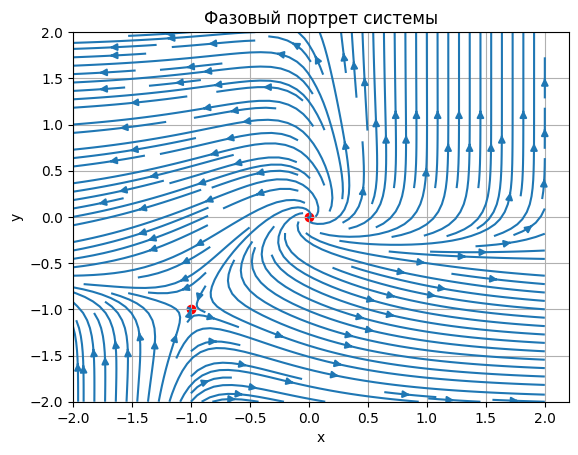

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def system(U, t):
    x, y = U
    dxdt = np.sinh(x - y)
    dydt = np.exp(2*x*y + x + y) - 1
    return [dxdt, dydt]

eq1 = [0, 0]
eq2 = [-1, -1]

def plot_phase_portrait():
    x = np.linspace(-2, 2, 20)
    y = np.linspace(-2, 2, 20)
    X, Y = np.meshgrid(x, y)
    DX, DY = system([X, Y], 0)
    plt.streamplot(X, Y, DX, DY, density=1.5)
    plt.scatter([eq1[0], eq2[0]], [eq1[1], eq2[1]], c='red')
    plt.xlabel('x'), plt.ylabel('y')
    plt.title('Фазовый портрет системы')
    plt.grid()
    plt.show()

plot_phase_portrait()

**Задание 2. Устойчивость линейных систем и систем первого приближения**

В этом задании мне нужно исследовать устойчивость положения равновесия (0, 0, 0) для системы

\begin{cases}
\dot{x} = -x + z \\
\dot{y} = -y - z \\
\dot{z} = y - z
\end{cases}

Для начала составлю Якобиан:
$$
J = \begin{pmatrix}
\frac{\partial \dot{x}}{\partial x} & \frac{\partial \dot{x}}{\partial y} & \frac{\partial \dot{x}}{\partial z} \\
\frac{\partial \dot{y}}{\partial x} & \frac{\partial \dot{y}}{\partial y} & \frac{\partial \dot{y}}{\partial z} \\
\frac{\partial \dot{z}}{\partial x} & \frac{\partial \dot{z}}{\partial y} & \frac{\partial \dot{z}}{\partial z}
\end{pmatrix} =
\begin{pmatrix}
-1 & 0 & 1 \\
0 & -1 & -1 \\
0 & 1 & -1 \\
\end{pmatrix}
$$


Теперь запишу характеристическое уравнение:


$$
\det(J - \lambda I) = \begin{vmatrix}
-1 - \lambda & 0 & 1 \\
0 & -1 - \lambda & -1 \\
0 & 1 & -1 - \lambda \\
\end{vmatrix} = (-1-\lambda)^3 - 1 \cdot(-1) \cdot (-1-\lambda) = (-1-\lambda)^3 + (-1-\lambda) = (-1-\lambda)((-1-\lambda)^2 +1)
$$

$$\lambda_1 = -1, \ \lambda_2 = -1 - i, \ \lambda_2 = -1 + i \quad \Rightarrow \quad \text{Устойчивый фокус}$$

Подытожу:
$$
\text{Re}(\lambda_k) < 0
$$ - система асимптотически устойчива

Также нарисую фазовый портрет системы в питоне:

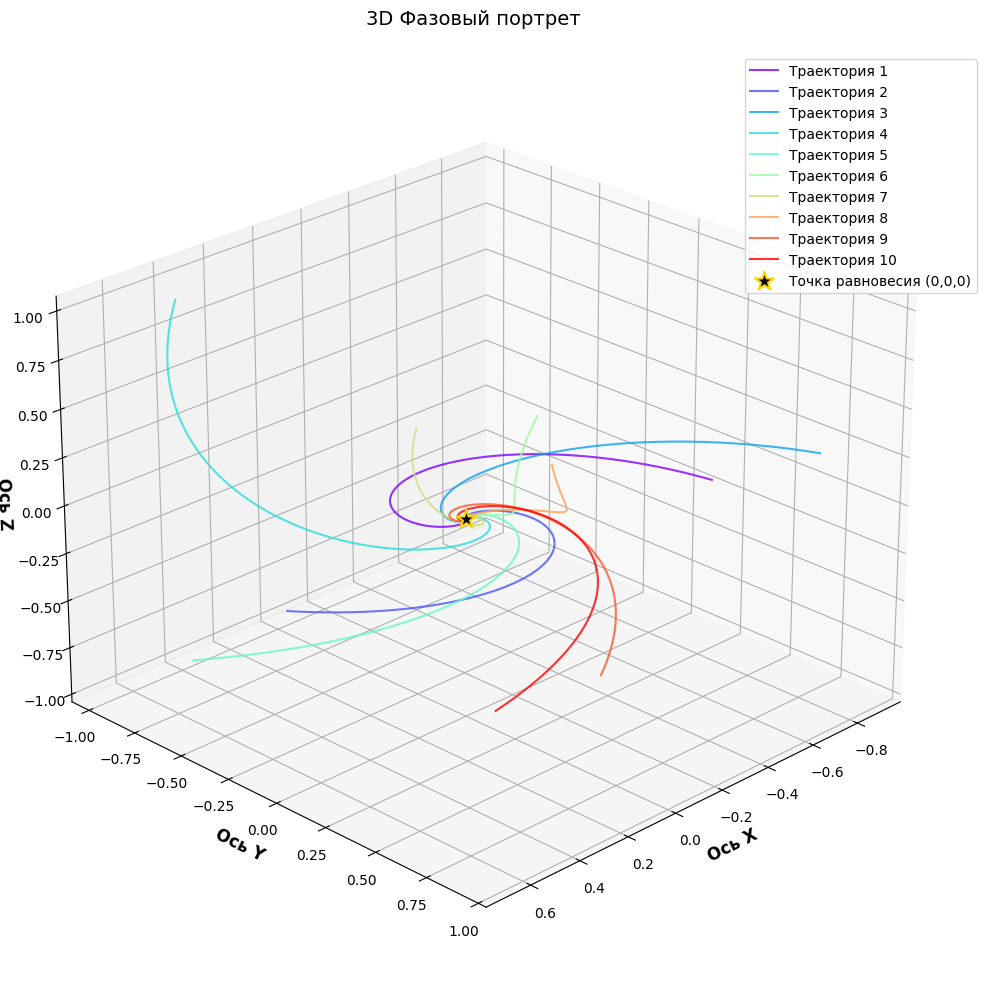

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.cm import rainbow

def calculateDerivatives(state, time):
    xCoord, yCoord, zCoord = state
    dxDt = -xCoord + zCoord
    dyDt = -yCoord - zCoord
    dzDt = yCoord - zCoord
    return [dxDt, dyDt, dzDt]

startTime = 0
endTime = 15
numTimePoints = 1000
timeArray = np.linspace(startTime, endTime, numTimePoints)

np.random.seed(42)
numTrajectories = 10 ## количество траекторий. Дальше - больше !
initialStates = np.random.uniform(-1, 1, (numTrajectories, 3))

colorPalette = rainbow(np.linspace(0, 1, numTrajectories))

fig = plt.figure(figsize=(12, 10))
axis3d = fig.add_subplot(111, projection='3d')

for trajectoryIdx in range(numTrajectories):
    currentColor = colorPalette[trajectoryIdx]
    solution = odeint(calculateDerivatives, initialStates[trajectoryIdx], timeArray)
    axis3d.plot(solution[:, 0], solution[:, 1], solution[:, 2],
              color=currentColor, linewidth=1.5, alpha=0.8,
              label=f'Траектория {trajectoryIdx+1}')

axis3d.scatter([0], [0], [0], c='black', s=200, marker='*',
              edgecolors='gold', linewidth=1.5,
              label='Точка равновесия (0,0,0)')

axis3d.set_xlabel('Ось X', fontsize=12, fontweight='bold')
axis3d.set_ylabel('Ось Y', fontsize=12, fontweight='bold')
axis3d.set_zlabel('Ось Z', fontsize=12, fontweight='bold')
axis3d.set_title('3D Фазовый портрет',
               fontsize=14, pad=20)
axis3d.legend(fontsize=10, bbox_to_anchor=(1.05, 1))
axis3d.grid(True, linestyle='--', alpha=0.5)
axis3d.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

**Задание 3. Функция Ляпунова. Теоремы Ляпунова и Четаева**

Тут мне надо рассмотреть эту систему ДУ
$$
\begin{cases}
\dot{x} = -3x^3 + y, \\
\dot{y} = -\frac{1}{3}x - y^3.
\end{cases}
$$

Функция Ляпунова:
$$
V(x,y) = \frac{1}{2}x^2 + \frac{3}{2}y^2
$$

Вычислим производную $V$ вдоль траекторий системы:
\begin{align*}
\dot{V}(x,y) &= \frac{\partial V}{\partial x}\dot{x} + \frac{\partial V}{\partial y}\dot{y} \\
&= x(-3x^3 + y) + 3y\left(-\frac{1}{3}x - y^3\right) \\
&= -3x^4 + xy - xy - 3y^4 \\
&= -3x^4 - 3y^4
\end{align*}

Получаем:
$$
\dot{V}(x,y) = -3(x^4 + y^4) < 0 \quad \forall (x,y) \neq (0,0)
$$

Производная $\dot{V}$ отрицательна везде, кроме точки $(0,0)$ $$\Rightarrow$$ имеем ассимптотическую устойчивость.

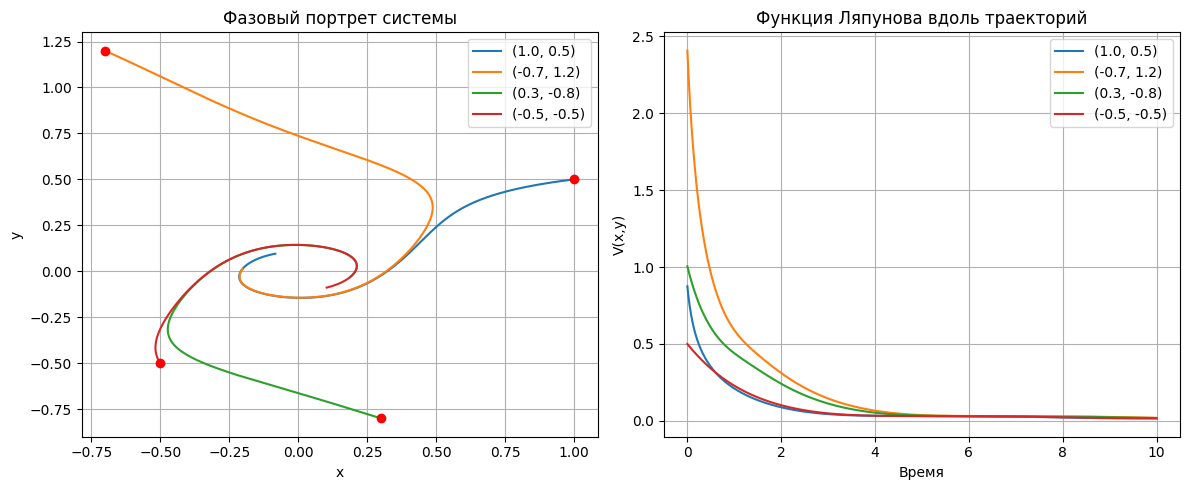

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def system(state, t):
    x, y = state
    dxdt = -3 * x**3 + y
    dydt = -(1/3) * x - y**3
    return [dxdt, dydt]

def lyapunovFunction(x, y):
    return 0.5 * x**2 + 1.5 * y**2

def lyapunovDerivative(x, y):
    return -3 * x**4 - 3 * y**4

initialConditions = [
    [1.0, 0.5],
    [-0.7, 1.2],
    [0.3, -0.8],
    [-0.5, -0.5],

]
timePoints = np.linspace(0, 10, 1000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for ic in initialConditions:
    trajectory = odeint(system, ic, timePoints)
    plt.plot(trajectory[:, 0], trajectory[:, 1], label=f'({ic[0]}, {ic[1]})')
    plt.plot(ic[0], ic[1], 'ro')
plt.title('Фазовый портрет системы')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for ic in initialConditions:
    trajectory = odeint(system, ic, timePoints)
    V = [lyapunovFunction(x, y) for x, y in trajectory]
    plt.plot(timePoints, V, label=f'({ic[0]}, {ic[1]})')
plt.title('Функция Ляпунова вдоль траекторий')
plt.xlabel('Время')
plt.ylabel('V(x,y)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


**Задание 4. Условия Рауса-Гурвица. Критерий Михайлова**

Иследую уравнение
$$
y^{(5)} + 2y^{(4)} + 4y''' + 6y'' + 5y' + 4y = 0
$$
по условию Рауса-Гурвица.

Составлю характеристичекий полином:
$$
P(s) = s^5 + 2s^4 + 4s^3 + 6s^2 + 5s + 4
$$

Итак, надо составить матрицу Гурвица. Она будет размером 5 на 5, так как старшая степень полинома = 5.

$$
H =
\begin{pmatrix}
2 \ 6 \ 4 \ 0 \ 0 \\
1 \ 4 \ 5 \ 0 \ 0 \\
0 \ 2 \ 6 \ 4 \ 0 \\
0 \ 1 \ 4 \ 5 \ 0 \\
0 \ 0 \ 2 \ 6 \ 4 \\
\end{pmatrix}
$$

Теперь расчитаю диагональные миноры:

$$
\Delta_1 = a_4 = 2 > 0
$$

$$
\Delta_2 = \begin{vmatrix}
2 & 6 \\
1 & 4 \\
\end{vmatrix} = (2 \cdot 4) - (6 \cdot 1) = 8 - 6 = 2 > 0
$$

$$
\Delta_3 = \begin{vmatrix}
2 & 6 & 4 \\
1 & 4 & 5 \\
0 & 2 & 6 \\
\end{vmatrix} = 2(24-10) - 6(6-0) + 4(2-0) = 0
$$


$$
\Delta_4 = \begin{vmatrix}
2 & 6 & 4 & 0 \\
1 & 4 & 5 & 0 \\
0 & 2 & 6 & 4 \\
0 & 1 & 4 & 5 \\
\end{vmatrix} = 8 > 0
$$

$$
\Delta_5 = a_0 \cdot \Delta_4 = 4 \cdot 8 = 32 > 0
$$

Система на границе устойчивости ($\Delta_3 = 0$)

**Задание 5. Исследование положений равновесия. Задачи с параметром**

Мне нужно исследовать, при каких значениях параметров a и b асимптотически
устойчиво нулевое решение для системы:
$$
\begin{cases}
\dot{x} = y + \sin(x) \\
\dot{y} = ax + by
\end{cases}
$$

Проверю точку (0; 0) на положение равновесия:
$$
\begin{cases}
y + \sin(x) = 0\\
 ax + by = 0
\end{cases}
$$
при
$$
\begin{cases}
y = 0\\
x = 0
\end{cases}
$$
$$
\begin{cases}
0 = 0\\
0 = 0
\end{cases}
$$
Значит это точка равновесия.


Построю матрицу Якоби:
$$
J = \begin{pmatrix}
\left. \dfrac{\partial \dot{x}}{\partial x} \right|_{(0,0)} &
\left. \dfrac{\partial \dot{x}}{\partial y} \right|_{(0,0)} \\
\left. \dfrac{\partial \dot{y}}{\partial x} \right|_{(0,0)} &
\left. \dfrac{\partial \dot{y}}{\partial y} \right|_{(0,0)}
\end{pmatrix}= \begin{pmatrix}
\cos(0) & 1 \\
a & b
\end{pmatrix}
= \begin{pmatrix}
1 & 1 \\
a & b
\end{pmatrix}.
$$

Составлю характеристическое уравнение:
$\det(J - \lambda I) = 0$
$$
\det \begin{pmatrix}
1 - \lambda & 1 \\
a & b - \lambda
\end{pmatrix}
= (1 - \lambda)(b - \lambda) - a = 0.
$$

$$
\lambda^2 - (b + 1)\lambda + (b - a) = 0.
$$

Для асимптотической устойчивости:
1. Все коэффициенты положительны:
$$
-(b + 1) > 0 \quad \text{и} \quad b - a > 0.
$$
2.Дискриминант должен быть неотрицателен
$$
(b + 1)^2 - 4(b - a) \geq 0 \\
b < -1 \quad \text{и} \quad b > a.
$$

Объеденю все условия:
$$
\boxed{
\begin{cases}
b < -1, \\
b > a.
\end{cases}}
$$

**Задание 6. Поведение фазовых траекторий системы**

Мне нужно рассмотреть систему
$$
\begin{cases}
\dot{x} = y(-a + x^2 + y^2) \\
\dot{y} = -x(-a + x^2 + y^2) \\
\end{cases}
$$

в окрестности положения равновесия $(0; 0)$

Матрица Якоби системы:
$$
J(x,y) = \begin{pmatrix}
\frac{\partial \dot{x}}{\partial x} & \frac{\partial \dot{x}}{\partial y} \\
\frac{\partial \dot{y}}{\partial x} & \frac{\partial \dot{y}}{\partial y}
\end{pmatrix} =
\begin{pmatrix}
2xy & -a + x^2 + 3y^2 \\
-a + 3x^2 + y^2 & -2xy
\end{pmatrix}.
$$


В точке $(0,0)$:
$$
J(0,0) = \begin{pmatrix}
0 & -a \\
-a & 0
\end{pmatrix}.
$$

Собственные значения этой матрицы: $\lambda = \pm a.$

- При а > 0  - седло
- При а < 0 - центр

Теперь перейду к полярным координатам:
($x = r\cos\theta$, $y = r\sin\theta$):

Теперь проанализирую:
Тут все траектории круги

**Задание 7. Уравнения гиперболического типа**

Система уравнений:
$$
\begin{cases}
9 \frac{\partial^2 u}{\partial t^2} = \frac{\partial^2 u}{\partial x^2}, \\
u_x'(0,t) = u_x'(2,t) = 0, \\
u\left(x,0\right) = \left\{ \begin{array}{ll}
x, & 0 \leq x \leq 1, \\
1, & 1 \leq x \leq 2, \\
\end{array} \right. \\
u_t'(x,0) = 0;
\end{cases}
$$

Предполагаем решение в виде:
$$
u(x,t) = X(x)T(t)
$$
Подставляем в уравнение:
$$
9X(x)T''(t) = X''(x)T(t) \implies \frac{T''}{T} = \frac{X''}{9X} = -\lambda
$$

Получаем два обычных диффура:
\begin{align*}
X'' + 9\lambda X &= 0 \\
T'' + \lambda T &= 0
\end{align*}

Сначала разбираемся с пространственной частью $X(x)$ с граничными условиями $X'(0) = X'(2) = 0$.

Случай 1: $\lambda = 0$

Решение:
$$
X_0(x) = A_0x + B_0
$$
Из граничных условий:
$$
X_0'(x) = A_0 = 0 \implies X_0(x) = B_0 \text{ (константа)}
$$

Случай 2: $\lambda > 0$

Общее решение:
$$
X(x) = C\cos(3\sqrt{\lambda}x) + D\sin(3\sqrt{\lambda}x)
$$
Применяем граничные условия:
\begin{align*}
X'(0) &= 3\sqrt{\lambda}D = 0 \implies D = 0 \\
X'(2) &= -3\sqrt{\lambda}C\sin(6\sqrt{\lambda}) = 0
\end{align*}
Получаем условие на $\lambda$:
$$
\sin(6\sqrt{\lambda}) = 0 \implies 6\sqrt{\lambda} = \pi n \implies \lambda_n = \left(\frac{\pi n}{6}\right)^2
$$
Таким образом, собственные функции:
$$
X_n(x) = \cos\left(\frac{\pi n x}{2}\right), \quad n = 0,1,2,...
$$

Для каждого $\lambda_n$ имеем:
$$
T_n'' + \left(\frac{\pi n}{6}\right)^2 T_n = 0
$$
Решение:
$$
T_n(t) = A_n\cos\left(\frac{\pi n t}{6}\right) + B_n\sin\left(\frac{\pi n t}{6}\right)
$$

Собираем всё вместе:
$$
u(x,t) = \sum_{n=0}^\infty \left[A_n\cos\left(\frac{\pi n t}{6}\right) + B_n\sin\left(\frac{\pi n t}{6}\right)\right]\cos\left(\frac{\pi n x}{2}\right)
$$

Из условия $u_t(x,0) = 0$ получаем:
$$
\sum_{n=1}^\infty B_n\frac{\pi n}{6}\cos\left(\frac{\pi n x}{2}\right) = 0 \implies B_n = 0 \text{ для всех } n
$$

Из условия на начальное положение:
$$
u(x,0) = \sum_{n=0}^\infty A_n\cos\left(\frac{\pi n x}{2}\right) =
\begin{cases}
x, & 0 \leq x \leq 1 \\
1, & 1 \leq x \leq 2
\end{cases}
$$

Коэффициенты Фурье:
\begin{align*}
A_0 &= \frac{1}{2}\int_0^2 u(x,0)dx = \frac{1}{2}\left(\int_0^1 x dx + \int_1^2 1 dx\right) = \frac{3}{4} \\
A_n &= \int_0^2 u(x,0)\cos\left(\frac{\pi n x}{2}\right)dx
\end{align*}

$$\boxed{
u(x,t) = \frac{3}{4} + \sum_{n=1}^\infty A_n\cos\left(\frac{\pi n x}{2}\right)\cos\left(\frac{\pi n t}{6}\right)}
$$



**Задание 8. Уравнения параболического типа**

Дано уравнение теплопроводности:
$$
2 \frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2}, \quad 0 < x < 2, \ t > 0
$$

$$
u(0,t) = 0, \quad \left.\frac{\partial u}{\partial x}\right|_{x=2} = 0
$$

$$
u(x,0) = x^2
$$

Ищем решение в виде:
$$
u(x,t) = X(x)T(t)
$$
Подставляем в уравнение:
$$
2X(x)T'(t) = X''(x)T(t) \implies \frac{T'}{T} = \frac{X''}{2X} = -\lambda
$$
Получаем систему:
\begin{align*}
X'' + 2\lambda X &= 0 \\
T' + \lambda T &= 0
\end{align*}

Граничные условия:
$$
X(0) = 0, \quad X'(2) = 0
$$

Рассмотрим случаи:

1. При $\lambda = 0$:
$$
X(x) = Ax + B
$$
Из граничных условий:
$$
X(0) = B = 0, \quad X'(2) = A = 0
$$
Получаем решение $X_0(x) = 0$.

2. При $\lambda > 0$:
Решение имеет вид:
$$
X(x) = C\cos(\sqrt{2\lambda}x) + D\sin(\sqrt{2\lambda}x)
$$
Применяем граничные условия:
\begin{align*}
X(0) &= C = 0 \\
X'(2) &= D\sqrt{2\lambda}\cos(2\sqrt{2\lambda}) = 0
\end{align*}
Получаем условие на $\lambda$:
$$
\cos(2\sqrt{2\lambda}) = 0 \implies 2\sqrt{2\lambda} = \frac{\pi}{2} + \pi n \implies \lambda_n = \frac{(\pi/2 + \pi n)^2}{8}
$$
Собственные функции:
$$
X_n(x) = \sin\left(\frac{(2n+1)\pi x}{4}\right), \quad n = 0,1,2,...
$$

Для каждого $\lambda_n$:
$$
T_n(t) = A_n e^{-\lambda_n t}
$$

$$
u(x,t) = \sum_{n=0}^\infty A_n \sin\left(\frac{(2n+1)\pi x}{4}\right) e^{-\frac{(\pi/2 + \pi n)^2}{8}t}
$$

Из начального условия:
$$
x^2 = \sum_{n=0}^\infty A_n \sin\left(\frac{(2n+1)\pi x}{4}\right)
$$
Коэффициенты Фурье:
$$
A_n = \frac{\int_0^2 x^2 \sin\left(\frac{(2n+1)\pi x}{4}\right) dx}{\int_0^2 \sin^2\left(\frac{(2n+1)\pi x}{4}\right) dx}
$$

После вычисления интегралов получаем:
$$
A_n = \frac{64[(-1)^n(8 - (2n+1)^2\pi^2) - 8]}{(2n+1)^3\pi^3}
$$

$$
\boxed{
u(x,t) = \sum_{n=0}^\infty \frac{64[(-1)^n(8 - (2n+1)^2\pi^2) - 8]}{(2n+1)^3\pi^3} \sin\left(\frac{(2n+1)\pi x}{4}\right) e^{-\frac{(2n+1)^2\pi^2}{32}t}}
$$


**Задание 9. Уравнения эллиптического типа**

$$
\begin{cases}
\Delta u = 0, & 0 \leq x \leq 2, \\
& 0 \leq y \leq 2,
\end{cases}
$$

$$\begin{cases}
u\left(x, 0\right) = \sin\left(\pi x\right), \\
u\left(x, 2\right) = \sin\left(2\pi x\right), \\
u\left(0, y\right) = u\left(2, y\right) = 0.
\end{cases}
$$

Самым простым cпособом, как решить эту задачу для меня было написать код на языке $Wolfram Matematica$

```wolfram
eqn = Laplacian[u[x, y], {x, y}] == 0;

bc = {u[x, 0] == Sin[Pi x], u[x, 2] == Sin[2 Pi x], u[0, y] == 0,
   u[2, y] == 0};

u[x_, y_] = (Sin[Pi x] Sinh[Pi (2 - y)])/
    Sinh[2 Pi] + (Sin[2 Pi x] Sinh[Pi y])/Sinh[4 Pi];

Print["Решение:"];
Print[TraditionalForm[u[x, y]]];

Plot3D[u[x, y], {x, 0, 2}, {y, 0, 2},
 PlotLabel -> "Решение уравнения Лапласа",
 AxesLabel -> {"x", "y", "u(x,y)"}, ColorFunction -> "Rainbow"]
```

Итак, вот такое получилось решение:
```wolfram
csch(2 \[Pi]) sin(\[Pi] x) sinh(\[Pi] (2-y))+csch(4 \[Pi]) sin(2 \[Pi] x) sinh(\[Pi] y)
```

на латехе:

$$
\mathrm{csch}(2\pi) \sin(\pi x) \sinh\bigl(\pi (2-y)\bigr) + \mathrm{csch}(4\pi) \sin(2\pi x) \sinh(\pi y)
$$


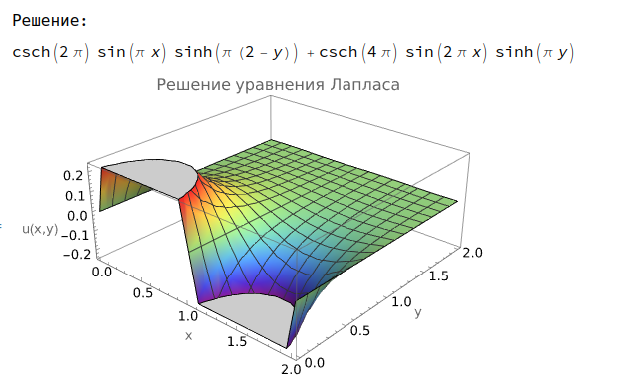

**Задание 10. Приведение уравнений к каноническому
виду**

$$x^2 u_{xx} - y^2 u_{yy} = 0$$

Коэффициенты:
\begin{align*}
A &= x^2, \quad B = 0, \quad C = -y^2 \\
D &= B^2 - 4AC = 4x^2y^2
\end{align*}

Тип:

- $D > 0$ при $xy \neq 0$: гиперболический
- $D = 0$ при $x=0$ или $y=0$: параболический


Гиперболический случай ($xy \neq 0$):

- Замена: $\xi = \frac{y}{x}$, $\eta = xy$
- Каноническая форма:
$$u_\xi - 2\eta u_{\xi\eta} = 0 \quad \text{(I/III четверти)}$$
$$u_\xi + 2\eta u_{\xi\eta} = 0 \quad \text{(II/IV четверти)}$$


Параболический случай:

- На $x=0$: $u_{yy} = 0$
- На $y=0$: $u_{xx} = 0$

Замены переменных
\begin{align*}
\text{I/III четверти} &: \xi = \frac{y}{x}, \eta = xy \\
\text{II/IV четверти} &: \xi = \frac{y}{|x|}, \eta = xy \\
\end{align*}
